# Predictive Maintenance — Equipment Failure Alert Prediction

**Objective**: Predict if equipment will trigger a maintenance alert in the next X days.

**Pipeline**:
1. Data Cleaning
2. EDA (by measurement type)
3. Feature Engineering & Label Creation (Health Index)
4. Model Training & Horizon Comparison

---

## Step 1 — Data Cleaning & Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
print('Libraries loaded')

Libraries loaded


In [2]:
# Load and clean data
df_raw = pd.read_excel('Documents_mesure_SAP.xlsx')

def french_to_float(value):
    if pd.isna(value): return np.nan
    if isinstance(value, (int, float)): return float(value)
    return float(str(value).replace(',', '.'))

df = df_raw.copy()
df.columns = ['equipment', 'sensor_id', 'date', 'time', 'value', 'unit', 'lower_limit', 'upper_limit']

for col in ['value', 'lower_limit', 'upper_limit']:
    df[col] = df[col].apply(french_to_float)

df['datetime'] = pd.to_datetime(
    df['date'].astype(str).str[:10] + ' ' + df['time'].astype(str),
    format='%Y-%m-%d %H:%M:%S', errors='coerce'
)
df = df.sort_values(['equipment', 'sensor_id', 'datetime']).reset_index(drop=True)
df = df.drop(columns=['date', 'time'])
df = df.dropna(subset=['value']).copy()
df['lower_limit'] = df['lower_limit'].fillna(0)

# Measurement types
def get_measure_type(unit):
    if pd.isna(unit): return 'Unknown'
    unit = str(unit).strip()
    if unit in ['\u00b0C']: return 'Temperature'
    elif unit == 'mm/s': return 'Vibration'
    elif unit == 'Bar': return 'Pressure'
    elif unit == 'mm': return 'Displacement'
    else: return 'Other'

df['measure_type'] = df['unit'].apply(get_measure_type)

# Fill missing thresholds
THRESHOLD_FILL = {
    ('MOTEUR_BROYEUR', 'Temperature'): 90.0,
    ('TURBOSOUFFLANTE', 'Displacement'): 130.0,
}
for (equip, mtype), limit in THRESHOLD_FILL.items():
    mask = (df['equipment'] == equip) & (df['measure_type'] == mtype) & (df['upper_limit'].isna())
    df.loc[mask, 'upper_limit'] = limit

# Compute threshold ratio per reading
df['threshold_ratio'] = np.where(
    df['upper_limit'].notna() & (df['upper_limit'] > 0),
    df['value'] / df['upper_limit'],
    np.nan
)

# Add date column for daily aggregation
df['date'] = df['datetime'].dt.date

print(f'Cleaned: {df.shape[0]} rows, {df["equipment"].nunique()} equipment')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Missing upper_limit: {df["upper_limit"].isna().sum()}')
df.head()

Cleaned: 583 rows, 4 equipment
Date range: 2026-05-05 to 2026-06-05
Missing upper_limit: 10


,equipment,sensor_id,value,unit,lower_limit,upper_limit,datetime,measure_type,threshold_ratio,date
0,BROYEUR_A_BOULETS,132813,0.03,mm/s,0.0,11.0,2026-05-05 00:49:02,Vibration,0.002727,2026-05-05
1,BROYEUR_A_BOULETS,132813,0.13,mm/s,0.0,11.0,2026-05-06 13:39:42,Vibration,0.011818,2026-05-06
2,BROYEUR_A_BOULETS,132813,0.03,mm/s,0.0,11.0,2026-05-07 00:00:34,Vibration,0.002727,2026-05-07
3,BROYEUR_A_BOULETS,132813,0.03,mm/s,0.0,11.0,2026-05-08 00:00:35,Vibration,0.002727,2026-05-08
4,BROYEUR_A_BOULETS,132813,0.03,mm/s,0.0,11.0,2026-05-09 00:00:36,Vibration,0.002727,2026-05-09


---

## Step 2 — EDA (by Measurement Type)

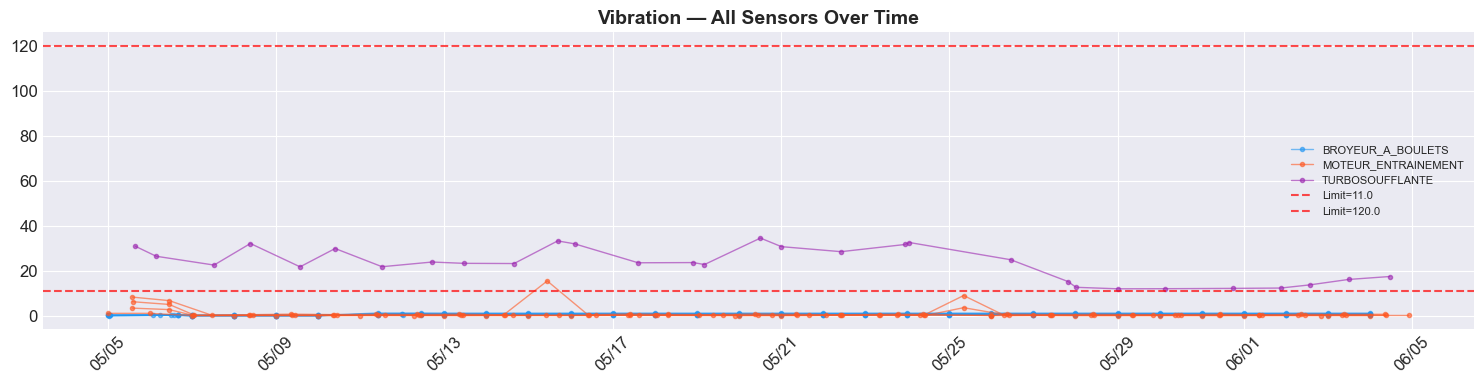

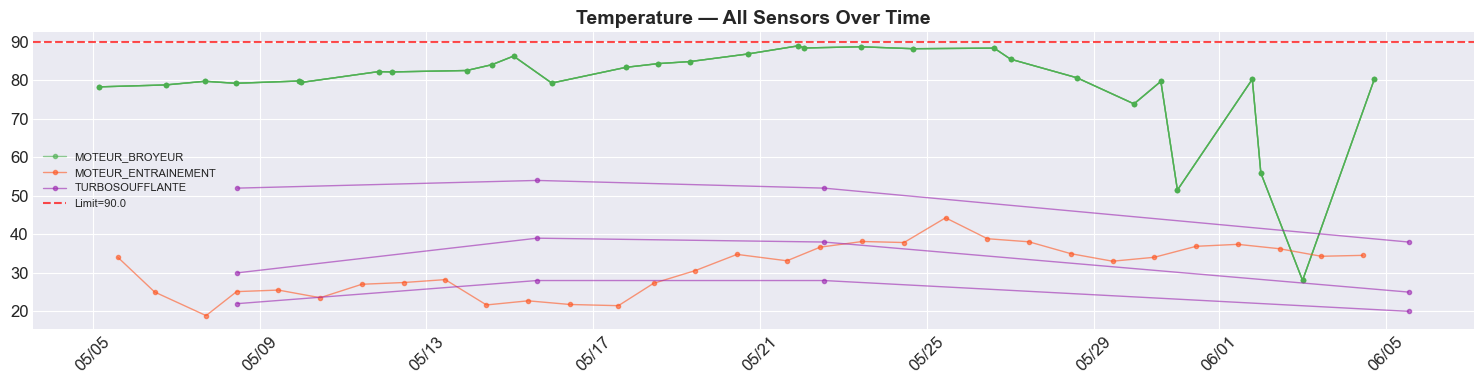

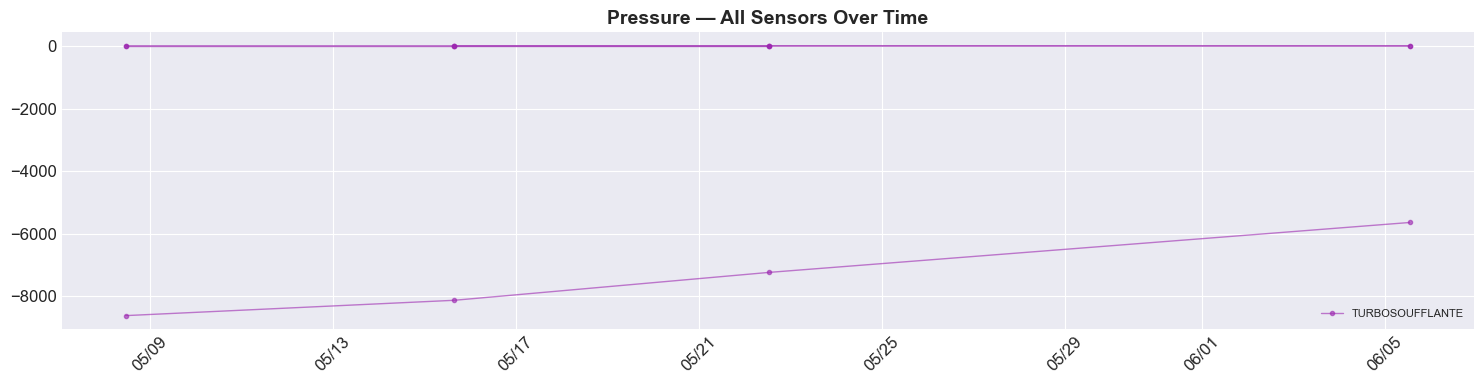

In [3]:
EQUIP_COLORS = {
    'BROYEUR_A_BOULETS': '#2196F3', 'MOTEUR_ENTRAINEMENT': '#FF5722',
    'MOTEUR_BROYEUR': '#4CAF50', 'TURBOSOUFFLANTE': '#9C27B0'
}
measure_types = [t for t in df['measure_type'].unique() if t not in ['Unknown', 'Other']]

# Time series by measurement type
for mtype in measure_types:
    mdata = df[df['measure_type'] == mtype]
    if len(mdata) < 5: continue
    fig, ax = plt.subplots(figsize=(15, 4))
    legend_added = set()
    for _, grp in mdata.groupby(['equipment', 'sensor_id']):
        grp = grp.sort_values('datetime')
        equip = grp['equipment'].iloc[0]
        color = EQUIP_COLORS.get(equip, '#999')
        label = equip if equip not in legend_added else None
        legend_added.add(equip)
        ax.plot(grp['datetime'], grp['value'], marker='o', markersize=3,
                linewidth=1, color=color, alpha=0.6, label=label)
    ulims = mdata[mdata['upper_limit'] > 0]['upper_limit'].dropna().unique()
    for lim in ulims:
        ax.axhline(y=lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Limit={lim}')
    ax.set_title(f'{mtype} — All Sensors Over Time', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

In [4]:
# Health state distribution
def classify_health(row):
    if pd.isna(row['upper_limit']) or row['upper_limit'] <= 0: return 'No Threshold'
    ratio = row['value'] / row['upper_limit']
    if ratio <= 0.8: return 'Normal'
    elif ratio <= 1.0: return 'Warning'
    else: return 'Critical'

df['health_state'] = df.apply(classify_health, axis=1)
print('=== Health State Distribution ===')
print(df['health_state'].value_counts())
print(f'\n% per state:')
print((df['health_state'].value_counts(normalize=True) * 100).round(1))

=== Health State Distribution ===
health_state
Normal          455
Warning         113
No Threshold     14
Critical          1
Name: count, dtype: int64

% per state:
health_state
Normal          78.0
Warning         19.4
No Threshold     2.4
Critical         0.2
Name: proportion, dtype: float64


---

## Step 3 — Feature Engineering & Label Creation

### Approach

**Health Index** = α × (distance-to-threshold score) + β × (stability score)

- **Distance-to-threshold score**: max(value / upper_limit) across all sensors per equipment per day
- **Stability score**: rolling coefficient of variation (instability indicator)
- **Alert label**: Health Index > alert_threshold → alert = 1
- **Prediction target**: Y = alert shifted forward by X days

### 3.1 — Hyperparameters

In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                    HYPERPARAMETERS                          ║
# ║           Adjust these values to experiment                 ║
# ╚══════════════════════════════════════════════════════════════╝

# Health Index weights
ALPHA = 0.6           # Weight for distance-to-threshold score
BETA = 0.4            # Weight for instability score

# Alert threshold on Health Index
ALERT_THRESHOLD = 0.7

# Rolling window for stability computation
ROLLING_WINDOW = 3    # days

# Prediction horizons to compare
PREDICTION_HORIZONS = [1, 2, 3, 5, 7]  # days ahead

print('Hyperparameters:')
print(f'  Alpha (threshold weight):  {ALPHA}')
print(f'  Beta (stability weight):   {BETA}')
print(f'  Alert threshold:           {ALERT_THRESHOLD}')
print(f'  Rolling window:            {ROLLING_WINDOW} days')
print(f'  Prediction horizons:       {PREDICTION_HORIZONS} days')

Hyperparameters:
  Alpha (threshold weight):  0.6
  Beta (stability weight):   0.4
  Alert threshold:           0.7
  Rolling window:            3 days
  Prediction horizons:       [1, 2, 3, 5, 7] days


### 3.2 — Aggregate Data: 1 Row per Equipment per Day

In [6]:
# Aggregate sensor readings per (equipment, day)
daily = df.groupby(['equipment', 'date']).agg(
    # Threshold ratio features
    threshold_ratio_max=('threshold_ratio', 'max'),
    threshold_ratio_mean=('threshold_ratio', 'mean'),
    threshold_ratio_std=('threshold_ratio', 'std'),
    
    # Value features
    value_mean=('value', 'mean'),
    value_max=('value', 'max'),
    value_min=('value', 'min'),
    value_std=('value', 'std'),
    
    # Count features
    n_readings=('value', 'count'),
    n_sensors=('sensor_id', 'nunique'),
).reset_index()

# Count sensors over limit per day
over_limit = df[df['threshold_ratio'] > 1.0].groupby(['equipment', 'date']).size().reset_index(name='n_over_limit')
daily = daily.merge(over_limit, on=['equipment', 'date'], how='left')
daily['n_over_limit'] = daily['n_over_limit'].fillna(0).astype(int)
daily['pct_over_limit'] = daily['n_over_limit'] / daily['n_sensors']

# Fill NaN std (happens when only 1 reading per day)
daily['threshold_ratio_std'] = daily['threshold_ratio_std'].fillna(0)
daily['value_std'] = daily['value_std'].fillna(0)

# Convert date to datetime for proper sorting
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['equipment', 'date']).reset_index(drop=True)

print(f'Daily aggregated data: {daily.shape}')
print(f'Rows per equipment:')
print(daily['equipment'].value_counts())
daily.head(10)

Daily aggregated data: (123, 13)
Rows per equipment:
equipment
BROYEUR_A_BOULETS      31
MOTEUR_ENTRAINEMENT    31
TURBOSOUFFLANTE        31
MOTEUR_BROYEUR         30
Name: count, dtype: int64


,equipment,date,threshold_ratio_max,threshold_ratio_mean,threshold_ratio_std,value_mean,value_max,value_min,value_std,n_readings,n_sensors,n_over_limit,pct_over_limit
0,BROYEUR_A_BOULETS,2026-05-05,0.018182,0.007841,0.004930,0.08625,0.20,0.03,0.054232,8,8,0,0.0
1,BROYEUR_A_BOULETS,2026-05-06,0.026364,0.016250,0.004672,0.17875,0.29,0.13,0.051391,8,8,0,0.0
2,BROYEUR_A_BOULETS,2026-05-07,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,8,0,0.0
3,BROYEUR_A_BOULETS,2026-05-08,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,8,0,0.0
4,BROYEUR_A_BOULETS,2026-05-09,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,8,0,0.0
5,BROYEUR_A_BOULETS,2026-05-10,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,8,0,0.0
6,BROYEUR_A_BOULETS,2026-05-11,0.106364,0.060455,0.022911,0.66500,1.17,0.39,0.252020,8,8,0,0.0
7,BROYEUR_A_BOULETS,2026-05-12,0.107273,0.063977,0.021791,0.70375,1.18,0.46,0.239698,8,8,0,0.0
8,BROYEUR_A_BOULETS,2026-05-13,0.102727,0.058864,0.021424,0.64750,1.13,0.41,0.235660,8,8,0,0.0
9,BROYEUR_A_BOULETS,2026-05-14,0.102727,0.058864,0.021424,0.64750,1.13,0.41,0.235660,8,8,0,0.0


### 3.3 — Compute Rolling Features (Stability / Instability)

In [7]:
# Compute rolling features per equipment (respecting time order)
rolling_features = []

for equip in daily['equipment'].unique():
    eq_data = daily[daily['equipment'] == equip].copy().sort_values('date')
    
    # Rolling statistics on threshold_ratio_max
    eq_data['rolling_mean'] = eq_data['threshold_ratio_max'].rolling(
        window=ROLLING_WINDOW, min_periods=1).mean()
    eq_data['rolling_std'] = eq_data['threshold_ratio_max'].rolling(
        window=ROLLING_WINDOW, min_periods=1).std().fillna(0)
    
    # Coefficient of variation (instability indicator)
    eq_data['rolling_cv'] = np.where(
        eq_data['rolling_mean'] > 0,
        eq_data['rolling_std'] / eq_data['rolling_mean'],
        0
    )
    
    # Rolling on value_mean
    eq_data['value_rolling_mean'] = eq_data['value_mean'].rolling(
        window=ROLLING_WINDOW, min_periods=1).mean()
    eq_data['value_rolling_std'] = eq_data['value_mean'].rolling(
        window=ROLLING_WINDOW, min_periods=1).std().fillna(0)
    
    # Rate of change (day-to-day)
    eq_data['delta_ratio'] = eq_data['threshold_ratio_max'].diff().fillna(0)
    eq_data['delta_value'] = eq_data['value_mean'].diff().fillna(0)
    
    # Acceleration (change of change)
    eq_data['delta_ratio_accel'] = eq_data['delta_ratio'].diff().fillna(0)
    
    rolling_features.append(eq_data)

daily = pd.concat(rolling_features, ignore_index=True)

print(f'Features added. Shape: {daily.shape}')
print(f'Columns: {daily.columns.tolist()}')
daily.head(10)

Features added. Shape: (123, 21)
Columns: ['equipment', 'date', 'threshold_ratio_max', 'threshold_ratio_mean', 'threshold_ratio_std', 'value_mean', 'value_max', 'value_min', 'value_std', 'n_readings', 'n_sensors', 'n_over_limit', 'pct_over_limit', 'rolling_mean', 'rolling_std', 'rolling_cv', 'value_rolling_mean', 'value_rolling_std', 'delta_ratio', 'delta_value', 'delta_ratio_accel']


,equipment,date,threshold_ratio_max,threshold_ratio_mean,threshold_ratio_std,value_mean,value_max,value_min,value_std,n_readings,...,n_over_limit,pct_over_limit,rolling_mean,rolling_std,rolling_cv,value_rolling_mean,value_rolling_std,delta_ratio,delta_value,delta_ratio_accel
0,BROYEUR_A_BOULETS,2026-05-05,0.018182,0.007841,0.004930,0.08625,0.20,0.03,0.054232,8,...,0,0.0,0.018182,0.000000,0.000000,0.086250,0.000000,0.000000,0.00000,0.000000
1,BROYEUR_A_BOULETS,2026-05-06,0.026364,0.016250,0.004672,0.17875,0.29,0.13,0.051391,8,...,0,0.0,0.022273,0.005785,0.259754,0.132500,0.065407,0.008182,0.09250,0.008182
2,BROYEUR_A_BOULETS,2026-05-07,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,...,0,0.0,0.016970,0.010055,0.592524,0.102083,0.070104,-0.020000,-0.13750,-0.028182
3,BROYEUR_A_BOULETS,2026-05-08,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,...,0,0.0,0.013030,0.011547,0.886166,0.087083,0.079386,0.000000,0.00000,0.020000
4,BROYEUR_A_BOULETS,2026-05-09,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,...,0,0.0,0.006364,0.000000,0.000000,0.041250,0.000000,0.000000,0.00000,0.000000
5,BROYEUR_A_BOULETS,2026-05-10,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,...,0,0.0,0.006364,0.000000,0.000000,0.041250,0.000000,0.000000,0.00000,0.000000
6,BROYEUR_A_BOULETS,2026-05-11,0.106364,0.060455,0.022911,0.66500,1.17,0.39,0.252020,8,...,0,0.0,0.039697,0.057735,1.454394,0.249167,0.360122,0.100000,0.62375,0.100000
7,BROYEUR_A_BOULETS,2026-05-12,0.107273,0.063977,0.021791,0.70375,1.18,0.46,0.239698,8,...,0,0.0,0.073333,0.057999,0.790899,0.470000,0.371814,0.000909,0.03875,-0.099091
8,BROYEUR_A_BOULETS,2026-05-13,0.102727,0.058864,0.021424,0.64750,1.13,0.41,0.235660,8,...,0,0.0,0.105455,0.002405,0.022808,0.672083,0.028786,-0.004545,-0.05625,-0.005455
9,BROYEUR_A_BOULETS,2026-05-14,0.102727,0.058864,0.021424,0.64750,1.13,0.41,0.235660,8,...,0,0.0,0.104242,0.002624,0.025175,0.666250,0.032476,0.000000,0.00000,0.004545


### 3.4 — Compute Health Index & Alert Labels

In [8]:
# --- Distance-to-threshold score ---
# Capped at [0, 1]: 0 = safe, 1 = at/above limit
daily['threshold_score'] = daily['threshold_ratio_max'].clip(0, 1)

# --- Instability score ---
# Normalize rolling_cv to [0, 1] using min-max per equipment
daily['instability_score'] = daily.groupby('equipment')['rolling_cv'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0
)

# --- Health Index ---
daily['health_index'] = ALPHA * daily['threshold_score'] + BETA * daily['instability_score']

# --- Alert label ---
daily['alert'] = (daily['health_index'] >= ALERT_THRESHOLD).astype(int)

print('=== Health Index Statistics ===')
print(daily[['equipment', 'threshold_score', 'instability_score', 'health_index', 'alert']].groupby('equipment').describe().round(3))

print(f'\n=== Alert Distribution ===')
print(daily['alert'].value_counts())
print(f'Alert rate: {daily["alert"].mean()*100:.1f}%')

=== Health Index Statistics ===
                    threshold_score                                            \
                              count   mean    std    min    25%    50%    75%   
equipment                                                                       
BROYEUR_A_BOULETS              31.0  0.085  0.037  0.006  0.103  0.103  0.103   
MOTEUR_BROYEUR                 30.0  0.878  0.141  0.311  0.881  0.905  0.948   
MOTEUR_ENTRAINEMENT            31.0  0.402  0.173  0.210  0.302  0.381  0.418   
TURBOSOUFFLANTE                31.0  0.279  0.253  0.099  0.139  0.196  0.260   

                           instability_score         ... health_index         \
                       max             count   mean  ...          75%    max   
equipment                                            ...                       
BROYEUR_A_BOULETS    0.107              31.0  0.089  ...        0.062  0.464   
MOTEUR_BROYEUR       0.988              30.0  0.148  ...        0.591  0.936   


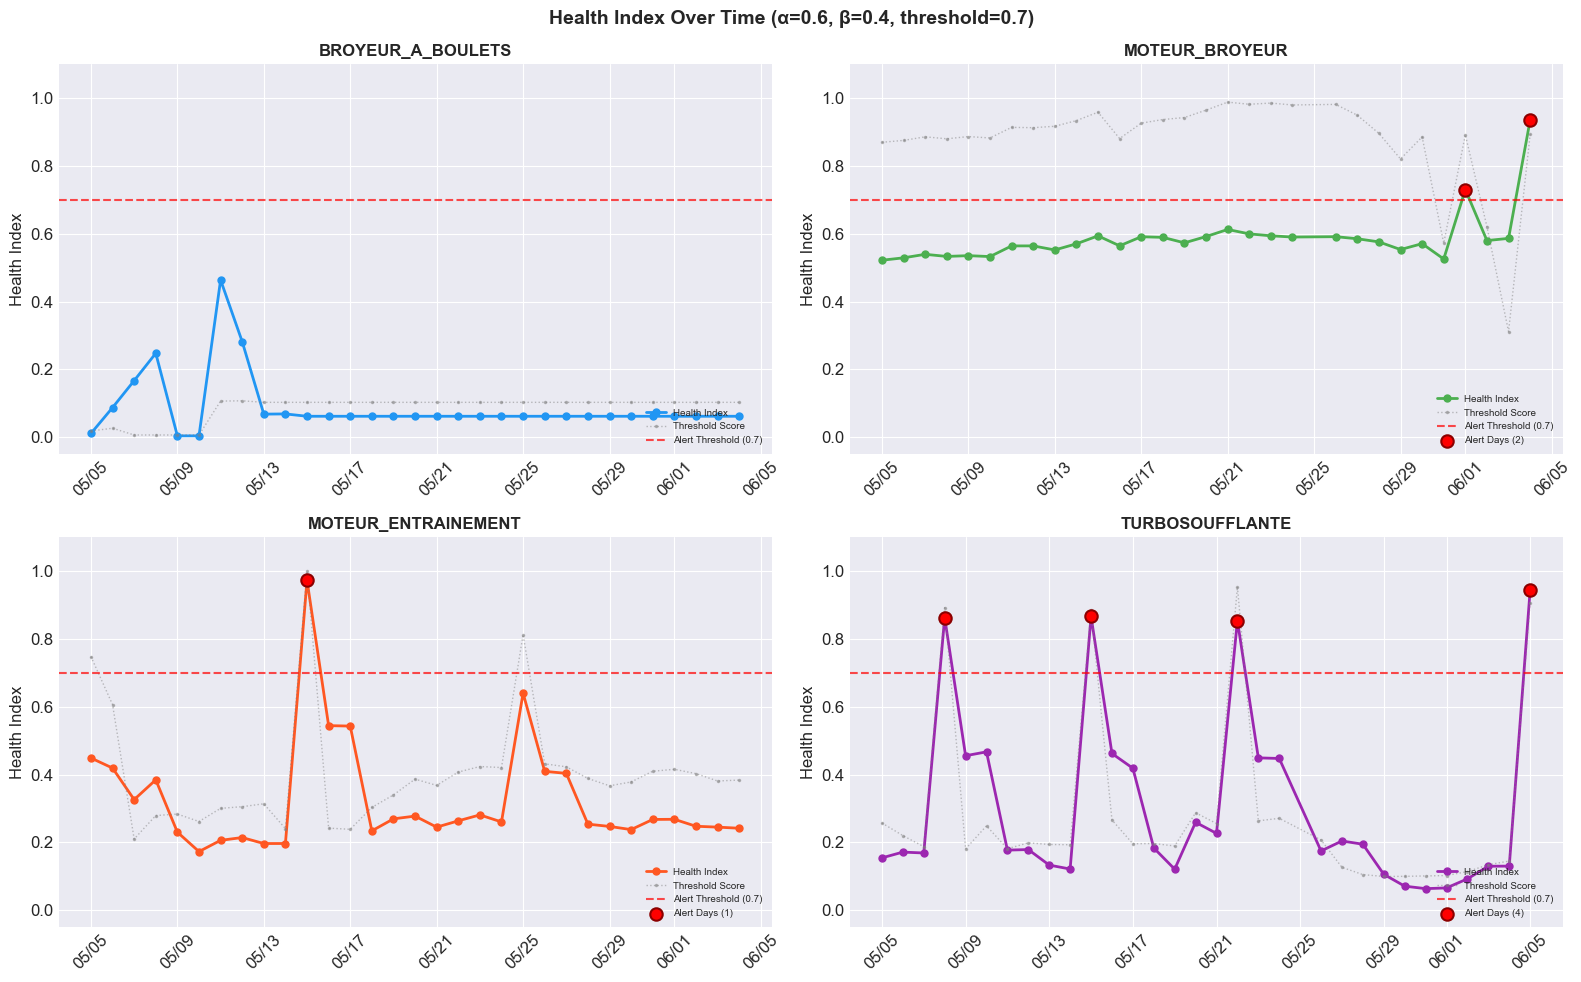

In [9]:
# Visualize Health Index over time per equipment
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, equip in enumerate(daily['equipment'].unique()):
    ax = axes[idx]
    eq_data = daily[daily['equipment'] == equip].sort_values('date')
    
    # Health Index line
    ax.plot(eq_data['date'], eq_data['health_index'],
            marker='o', markersize=5, linewidth=2, color=EQUIP_COLORS.get(equip, '#333'),
            label='Health Index')
    
    # Threshold score component
    ax.plot(eq_data['date'], eq_data['threshold_score'],
            marker='.', markersize=3, linewidth=1, color='gray', alpha=0.5,
            label='Threshold Score', linestyle=':')
    
    # Alert threshold line
    ax.axhline(y=ALERT_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Alert Threshold ({ALERT_THRESHOLD})')
    
    # Color alert days
    alert_days = eq_data[eq_data['alert'] == 1]
    if len(alert_days) > 0:
        ax.scatter(alert_days['date'], alert_days['health_index'],
                  c='red', s=80, zorder=5, edgecolors='darkred', linewidth=1.5,
                  label=f'Alert Days ({len(alert_days)})')
    
    ax.set_title(equip, fontsize=12, fontweight='bold')
    ax.set_ylabel('Health Index')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=7, loc='lower right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Health Index Over Time (\u03b1={ALPHA}, \u03b2={BETA}, threshold={ALERT_THRESHOLD})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

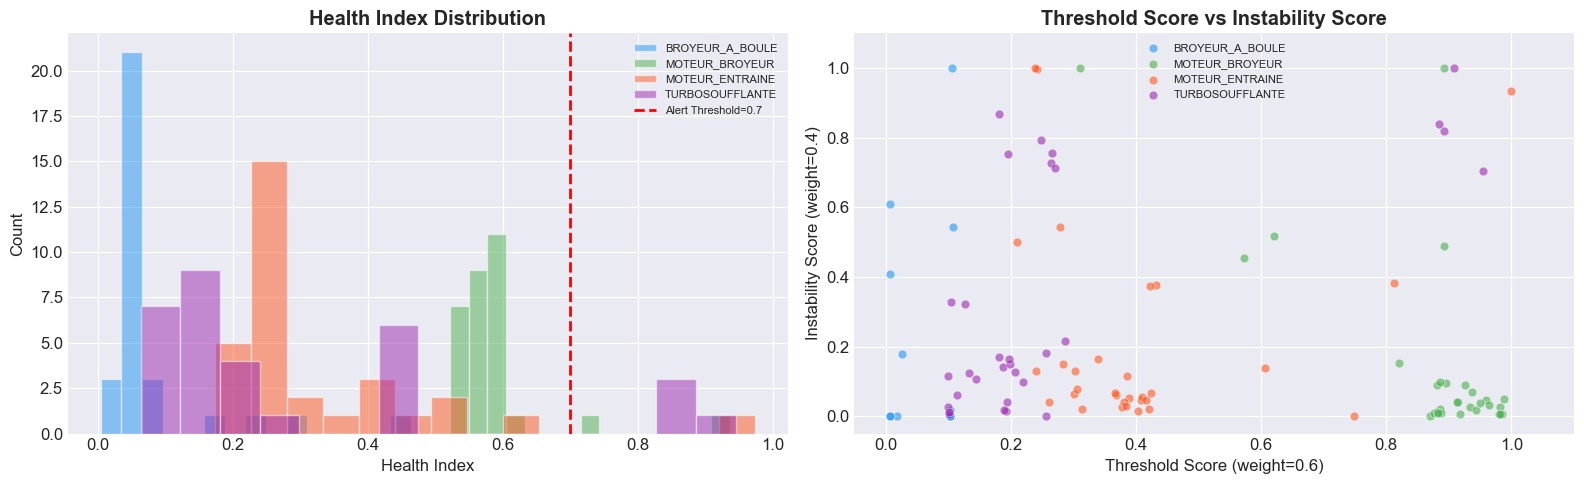

In [10]:
# Visualize the two components of Health Index
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Health Index distribution
for equip in daily['equipment'].unique():
    eq_data = daily[daily['equipment'] == equip]
    axes[0].hist(eq_data['health_index'], bins=15, alpha=0.5,
                color=EQUIP_COLORS.get(equip, '#999'), label=equip[:15], edgecolor='white')
axes[0].axvline(x=ALERT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Alert Threshold={ALERT_THRESHOLD}')
axes[0].set_title('Health Index Distribution', fontweight='bold')
axes[0].set_xlabel('Health Index')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Right: Threshold Score vs Instability Score scatter
for equip in daily['equipment'].unique():
    eq_data = daily[daily['equipment'] == equip]
    axes[1].scatter(eq_data['threshold_score'], eq_data['instability_score'],
                   c=EQUIP_COLORS.get(equip, '#999'), s=40, alpha=0.6,
                   label=equip[:15], edgecolors='white', linewidth=0.5)
axes[1].set_title('Threshold Score vs Instability Score', fontweight='bold')
axes[1].set_xlabel(f'Threshold Score (weight={ALPHA})')
axes[1].set_ylabel(f'Instability Score (weight={BETA})')
axes[1].legend(fontsize=8)
axes[1].set_xlim(-0.05, 1.1)
axes[1].set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### 3.5 — Create Shifted Labels for Each Prediction Horizon

In [11]:
# For each horizon X, create Y = "will there be an alert in X days?"
for horizon in PREDICTION_HORIZONS:
    col_name = f'alert_in_{horizon}d'
    # Shift alert backward by X days (so today's row gets tomorrow+X's label)
    daily[col_name] = daily.groupby('equipment')['alert'].shift(-horizon)

# Show label distribution per horizon
print('=== Label Distribution per Prediction Horizon ===')
for horizon in PREDICTION_HORIZONS:
    col = f'alert_in_{horizon}d'
    valid = daily[col].dropna()
    n_alert = int(valid.sum())
    n_total = len(valid)
    pct = n_alert / n_total * 100 if n_total > 0 else 0
    print(f'  Horizon {horizon}d: {n_total} samples, {n_alert} alerts ({pct:.1f}%), {n_total - n_alert} normal ({100-pct:.1f}%)')

daily.head(10)

=== Label Distribution per Prediction Horizon ===
  Horizon 1d: 119 samples, 7 alerts (5.9%), 112 normal (94.1%)
  Horizon 2d: 115 samples, 7 alerts (6.1%), 108 normal (93.9%)
  Horizon 3d: 111 samples, 7 alerts (6.3%), 104 normal (93.7%)
  Horizon 5d: 103 samples, 6 alerts (5.8%), 97 normal (94.2%)
  Horizon 7d: 95 samples, 6 alerts (6.3%), 89 normal (93.7%)


,equipment,date,threshold_ratio_max,threshold_ratio_mean,threshold_ratio_std,value_mean,value_max,value_min,value_std,n_readings,...,delta_ratio_accel,threshold_score,instability_score,health_index,alert,alert_in_1d,alert_in_2d,alert_in_3d,alert_in_5d,alert_in_7d
0,BROYEUR_A_BOULETS,2026-05-05,0.018182,0.007841,0.004930,0.08625,0.20,0.03,0.054232,8,...,0.000000,0.018182,0.000000,0.010909,0,0.0,0.0,0.0,0.0,0.0
1,BROYEUR_A_BOULETS,2026-05-06,0.026364,0.016250,0.004672,0.17875,0.29,0.13,0.051391,8,...,0.008182,0.026364,0.178599,0.087258,0,0.0,0.0,0.0,0.0,0.0
2,BROYEUR_A_BOULETS,2026-05-07,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,...,-0.028182,0.006364,0.407402,0.166779,0,0.0,0.0,0.0,0.0,0.0
3,BROYEUR_A_BOULETS,2026-05-08,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,...,0.020000,0.006364,0.609302,0.247539,0,0.0,0.0,0.0,0.0,0.0
4,BROYEUR_A_BOULETS,2026-05-09,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,...,0.000000,0.006364,0.000000,0.003818,0,0.0,0.0,0.0,0.0,0.0
5,BROYEUR_A_BOULETS,2026-05-10,0.006364,0.003750,0.001325,0.04125,0.07,0.03,0.014577,8,...,0.000000,0.006364,0.000000,0.003818,0,0.0,0.0,0.0,0.0,0.0
6,BROYEUR_A_BOULETS,2026-05-11,0.106364,0.060455,0.022911,0.66500,1.17,0.39,0.252020,8,...,0.100000,0.106364,1.000000,0.463818,0,0.0,0.0,0.0,0.0,0.0
7,BROYEUR_A_BOULETS,2026-05-12,0.107273,0.063977,0.021791,0.70375,1.18,0.46,0.239698,8,...,-0.099091,0.107273,0.543800,0.281883,0,0.0,0.0,0.0,0.0,0.0
8,BROYEUR_A_BOULETS,2026-05-13,0.102727,0.058864,0.021424,0.64750,1.13,0.41,0.235660,8,...,-0.005455,0.102727,0.015682,0.067909,0,0.0,0.0,0.0,0.0,0.0
9,BROYEUR_A_BOULETS,2026-05-14,0.102727,0.058864,0.021424,0.64750,1.13,0.41,0.235660,8,...,0.004545,0.102727,0.017310,0.068560,0,0.0,0.0,0.0,0.0,0.0


### 3.6 — Define Feature Matrix

In [12]:
# Features used by the model
# Note: we do NOT include health_index, threshold_score, or instability_score
# as features because they are used to CREATE the label.
# The model must learn from raw/engineered sensor features.

FEATURE_COLS = [
    # Daily aggregated sensor readings
    'threshold_ratio_max',      # Max value/limit ratio across sensors
    'threshold_ratio_mean',     # Mean value/limit ratio
    'threshold_ratio_std',      # Spread of ratios across sensors
    'value_mean',               # Mean sensor value
    'value_max',                # Max sensor value
    'value_std',                # Variability across sensors
    'n_over_limit',             # Count of sensors exceeding limit
    'pct_over_limit',           # % of sensors exceeding limit
    
    # Rolling / stability features
    'rolling_mean',             # 3-day rolling mean of max ratio
    'rolling_std',              # 3-day rolling std of max ratio
    'rolling_cv',               # Coefficient of variation (instability)
    'value_rolling_mean',       # 3-day rolling mean of values
    'value_rolling_std',        # 3-day rolling std of values
    
    # Rate of change features
    'delta_ratio',              # Day-to-day change in max ratio
    'delta_value',              # Day-to-day change in mean value
    'delta_ratio_accel',        # Acceleration of ratio change
]

print(f'Feature columns ({len(FEATURE_COLS)}):')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

# Add equipment encoding
daily['equipment_encoded'] = pd.Categorical(daily['equipment']).codes
FEATURE_COLS.append('equipment_encoded')
print(f'  {len(FEATURE_COLS):2d}. equipment_encoded')

print(f'\nTotal features: {len(FEATURE_COLS)}')

Feature columns (16):
   1. threshold_ratio_max
   2. threshold_ratio_mean
   3. threshold_ratio_std
   4. value_mean
   5. value_max
   6. value_std
   7. n_over_limit
   8. pct_over_limit
   9. rolling_mean
  10. rolling_std
  11. rolling_cv
  12. value_rolling_mean
  13. value_rolling_std
  14. delta_ratio
  15. delta_value
  16. delta_ratio_accel
  17. equipment_encoded

Total features: 17


---

## Step 4 — Model Training & Horizon Comparison

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
    print('XGBoost available')
except ImportError:
    HAS_XGBOOST = False
    print('XGBoost not available, using Random Forest only')

print('Model libraries loaded')

XGBoost not available, using Random Forest only
Model libraries loaded


### 4.1 — Train & Evaluate for Each Prediction Horizon

In [14]:
# Store results for comparison
results = []

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=3)

for horizon in PREDICTION_HORIZONS:
    target_col = f'alert_in_{horizon}d'
    
    # Prepare data: drop rows where target is NaN (last X days)
    model_data = daily.dropna(subset=[target_col] + FEATURE_COLS).copy()
    model_data = model_data.sort_values('date').reset_index(drop=True)
    
    X = model_data[FEATURE_COLS].values
    y = model_data[target_col].astype(int).values
    
    if len(X) < 10 or len(np.unique(y)) < 2:
        print(f'Horizon {horizon}d: Not enough data or only one class. Skipping.')
        continue
    
    # --- Random Forest ---
    rf_scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        rf = RandomForestClassifier(
            n_estimators=100, max_depth=5, min_samples_leaf=3,
            random_state=42, class_weight='balanced'
        )
        rf.fit(X_train_s, y_train)
        y_pred = rf.predict(X_test_s)
        
        rf_scores['accuracy'].append(accuracy_score(y_test, y_pred))
        rf_scores['precision'].append(precision_score(y_test, y_pred, zero_division=0))
        rf_scores['recall'].append(recall_score(y_test, y_pred, zero_division=0))
        rf_scores['f1'].append(f1_score(y_test, y_pred, zero_division=0))
    
    results.append({
        'Horizon': f'{horizon}d',
        'Model': 'Random Forest',
        'Samples': len(X),
        'Alert %': f'{y.mean()*100:.1f}%',
        'Accuracy': np.mean(rf_scores['accuracy']),
        'Precision': np.mean(rf_scores['precision']),
        'Recall': np.mean(rf_scores['recall']),
        'F1': np.mean(rf_scores['f1']),
    })
    
    # --- XGBoost ---
    if HAS_XGBOOST:
        xgb_scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
        
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_test_s = scaler.transform(X_test)
            
            # Handle class imbalance
            n_pos = y_train.sum()
            n_neg = len(y_train) - n_pos
            scale_pos = n_neg / max(n_pos, 1)
            
            xgb = XGBClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                min_child_weight=3, scale_pos_weight=scale_pos,
                random_state=42, eval_metric='logloss', verbosity=0
            )
            xgb.fit(X_train_s, y_train)
            y_pred = xgb.predict(X_test_s)
            
            xgb_scores['accuracy'].append(accuracy_score(y_test, y_pred))
            xgb_scores['precision'].append(precision_score(y_test, y_pred, zero_division=0))
            xgb_scores['recall'].append(recall_score(y_test, y_pred, zero_division=0))
            xgb_scores['f1'].append(f1_score(y_test, y_pred, zero_division=0))
        
        results.append({
            'Horizon': f'{horizon}d',
            'Model': 'XGBoost',
            'Samples': len(X),
            'Alert %': f'{y.mean()*100:.1f}%',
            'Accuracy': np.mean(xgb_scores['accuracy']),
            'Precision': np.mean(xgb_scores['precision']),
            'Recall': np.mean(xgb_scores['recall']),
            'F1': np.mean(xgb_scores['f1']),
        })
    
    print(f'Horizon {horizon}d: done ({len(X)} samples, {y.mean()*100:.1f}% alerts)')

print('\nAll horizons processed.')

Horizon 1d: done (119 samples, 5.9% alerts)


Horizon 2d: done (115 samples, 6.1% alerts)


Horizon 3d: done (111 samples, 6.3% alerts)


Horizon 5d: done (103 samples, 5.8% alerts)


Horizon 7d: done (95 samples, 6.3% alerts)

All horizons processed.


### 4.2 — Results Comparison Table

In [15]:
df_results = pd.DataFrame(results)
df_results[['Accuracy', 'Precision', 'Recall', 'F1']] = df_results[['Accuracy', 'Precision', 'Recall', 'F1']].round(3)

print('=== Model Performance Comparison Across Prediction Horizons ===')
print()
df_results

=== Model Performance Comparison Across Prediction Horizons ===



,Horizon,Model,Samples,Alert %,Accuracy,Precision,Recall,F1
0,1d,Random Forest,119,5.9%,0.920,0.000,0.000,0.000
1,2d,Random Forest,115,6.1%,0.929,0.000,0.000,0.000
2,3d,Random Forest,111,6.3%,0.901,0.000,0.000,0.000
3,5d,Random Forest,103,5.8%,0.933,0.000,0.000,0.000
4,7d,Random Forest,95,6.3%,0.913,0.167,0.333,0.222


### 4.3 — Performance vs Prediction Horizon (Visualization)

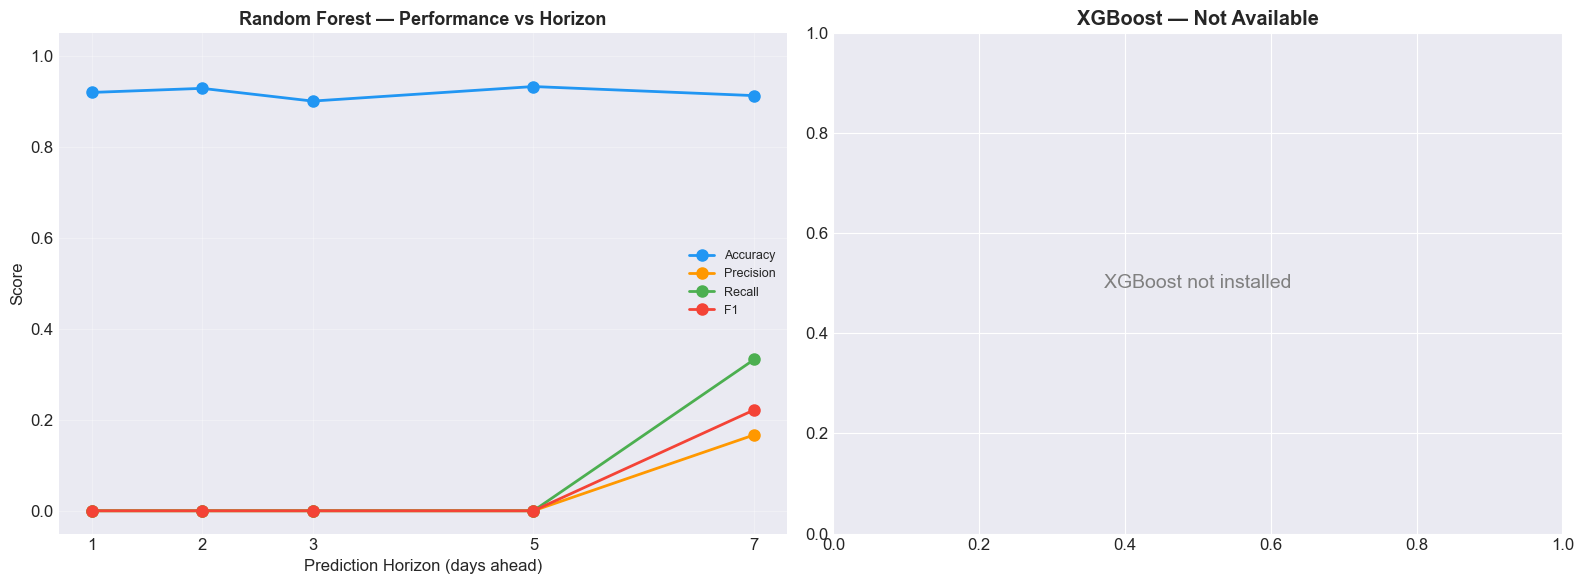

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors_metrics = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']

for model_name, ax in zip(['Random Forest', 'XGBoost'] if HAS_XGBOOST else ['Random Forest'], axes if HAS_XGBOOST else [axes[0]]):
    model_results = df_results[df_results['Model'] == model_name]
    if len(model_results) == 0:
        continue
    
    horizons_numeric = [int(h.replace('d', '')) for h in model_results['Horizon']]
    
    for metric, color in zip(metrics, colors_metrics):
        ax.plot(horizons_numeric, model_results[metric].values,
                marker='o', markersize=8, linewidth=2, color=color,
                label=metric)
    
    ax.set_title(f'{model_name} — Performance vs Horizon', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prediction Horizon (days ahead)')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(horizons_numeric)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# If no XGBoost, use right panel for F1 comparison
if not HAS_XGBOOST:
    axes[1].text(0.5, 0.5, 'XGBoost not installed', ha='center', va='center',
                fontsize=14, color='gray', transform=axes[1].transAxes)
    axes[1].set_title('XGBoost — Not Available', fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
# F1 Score comparison: RF vs XGBoost across horizons
if HAS_XGBOOST and len(df_results) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    rf_results = df_results[df_results['Model'] == 'Random Forest']
    xgb_results = df_results[df_results['Model'] == 'XGBoost']
    
    horizons = [int(h.replace('d', '')) for h in rf_results['Horizon']]
    x = np.arange(len(horizons))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, rf_results['F1'].values, width,
                   label='Random Forest', color='#2196F3', alpha=0.8, edgecolor='white')
    bars2 = ax.bar(x + width/2, xgb_results['F1'].values, width,
                   label='XGBoost', color='#FF5722', alpha=0.8, edgecolor='white')
    
    # Add value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{h} days' for h in horizons])
    ax.set_xlabel('Prediction Horizon')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score: Random Forest vs XGBoost by Horizon', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

### 4.4 — Feature Importance

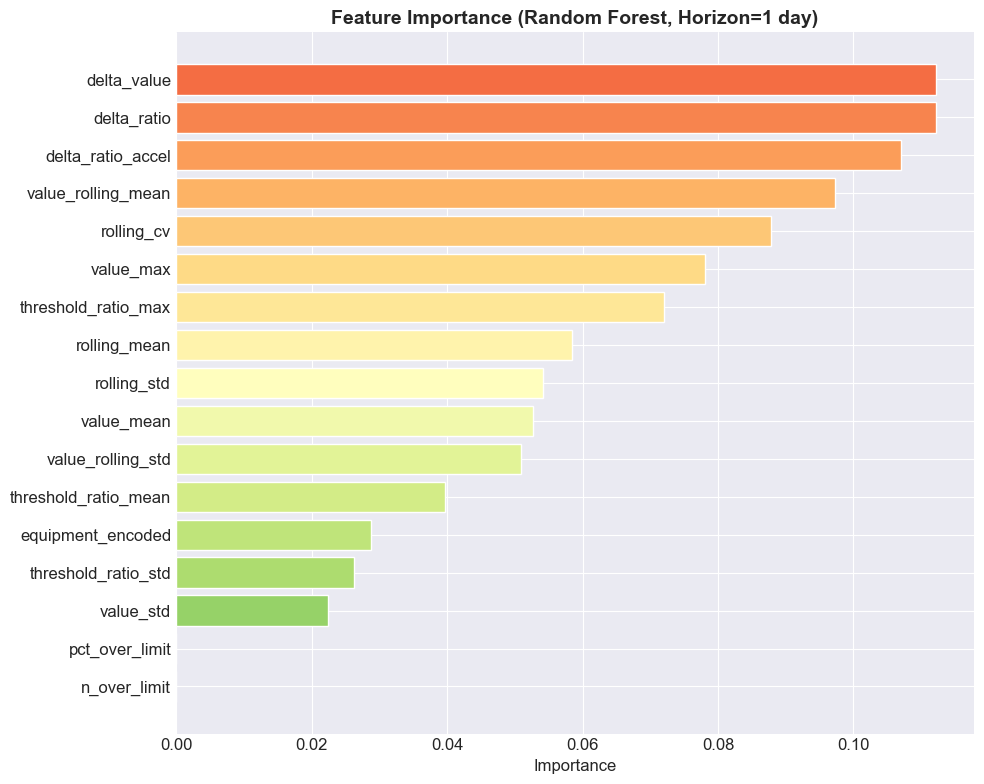


Top 5 most important features:
  delta_value: 0.1122
  delta_ratio: 0.1122
  delta_ratio_accel: 0.1071
  value_rolling_mean: 0.0972
  rolling_cv: 0.0879


In [18]:
# Train final model on horizon=1 for feature importance analysis
target_col = 'alert_in_1d'
model_data = daily.dropna(subset=[target_col] + FEATURE_COLS).copy()
model_data = model_data.sort_values('date').reset_index(drop=True)

X_all = model_data[FEATURE_COLS].values
y_all = model_data[target_col].astype(int).values

scaler = StandardScaler()
X_all_s = scaler.fit_transform(X_all)

# Train Random Forest on all data for feature importance
rf_final = RandomForestClassifier(
    n_estimators=200, max_depth=5, min_samples_leaf=3,
    random_state=42, class_weight='balanced'
)
rf_final.fit(X_all_s, y_all)

# Feature importance
importances = rf_final.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feat_imp)))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors, edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance (Random Forest, Horizon=1 day)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
    print(f'  {row["Feature"]}: {row["Importance"]:.4f}')

### 4.5 — Confusion Matrices (Horizon = 1 day)


=== Random Forest — Classification Report (1-day horizon) ===
Test set: 24 samples (3 alerts, 21 normal)
              precision    recall  f1-score   support

      Normal       0.88      1.00      0.93        21
       Alert       0.00      0.00      0.00         3

    accuracy                           0.88        24
   macro avg       0.44      0.50      0.47        24
weighted avg       0.77      0.88      0.82        24



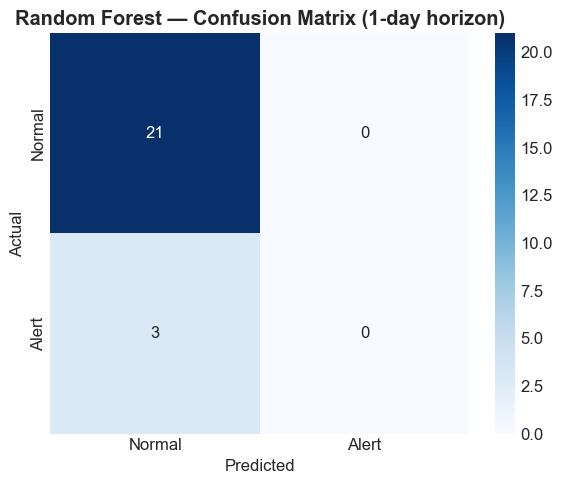

In [19]:
# Train/test split for confusion matrix (last 20% as test)
split_idx = int(len(X_all) * 0.8)
X_train, X_test = X_all_s[:split_idx], X_all_s[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

models = {'Random Forest': RandomForestClassifier(
    n_estimators=200, max_depth=5, min_samples_leaf=3,
    random_state=42, class_weight='balanced'
)}

if HAS_XGBOOST:
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        min_child_weight=3, scale_pos_weight=n_neg/max(n_pos, 1),
        random_state=42, eval_metric='logloss', verbosity=0
    )

fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Alert'],
                yticklabels=['Normal', 'Alert'])
    ax.set_title(f'{name} — Confusion Matrix (1-day horizon)', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    
    print(f'\n=== {name} — Classification Report (1-day horizon) ===')
    print(f'Test set: {len(y_test)} samples ({y_test.sum()} alerts, {len(y_test)-y_test.sum()} normal)')
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Alert'], zero_division=0))

plt.tight_layout()
plt.show()

### 4.6 — Summary & Conclusion

In [20]:
print('=' * 70)
print('PROJECT SUMMARY')
print('=' * 70)

print(f'\nDATA:')
print(f'  Source: Documents_mesure_SAP.xlsx')
print(f'  Raw readings: {len(df)} sensor measurements')
print(f'  Equipment: {df["equipment"].nunique()} types')
print(f'  Date range: {df["date"].min()} to {df["date"].max()}')
print(f'  After daily aggregation: {len(daily)} rows')

print(f'\nHEALTH INDEX:')
print(f'  Formula: HI = {ALPHA} x threshold_score + {BETA} x instability_score')
print(f'  Alert threshold: {ALERT_THRESHOLD}')
print(f'  Rolling window: {ROLLING_WINDOW} days')

print(f'\nMODEL RESULTS:')
print(df_results.to_string(index=False))

print(f'\nKEY OBSERVATIONS:')
if len(df_results) > 0:
    best = df_results.loc[df_results['F1'].idxmax()]
    print(f'  Best F1 Score: {best["F1"]:.3f} ({best["Model"]}, horizon={best["Horizon"]})')
print(f'  Features: {len(FEATURE_COLS)} engineered features')
print(f'  Approach: Combined threshold distance + stability (variance)')

print(f'\nLIMITATIONS:')
print(f'  - Small dataset ({len(daily)} daily samples)')
print(f'  - No real failure events (labels are synthetic from Health Index)')
print(f'  - Only 1 month of data — longer history would improve model')
print('=' * 70)

PROJECT SUMMARY

DATA:
  Source: Documents_mesure_SAP.xlsx
  Raw readings: 583 sensor measurements
  Equipment: 4 types
  Date range: 2026-05-05 to 2026-06-05
  After daily aggregation: 123 rows

HEALTH INDEX:
  Formula: HI = 0.6 x threshold_score + 0.4 x instability_score
  Alert threshold: 0.7
  Rolling window: 3 days

MODEL RESULTS:
Horizon         Model  Samples Alert %  Accuracy  Precision  Recall    F1
     1d Random Forest      119    5.9%     0.920      0.000   0.000 0.000
     2d Random Forest      115    6.1%     0.929      0.000   0.000 0.000
     3d Random Forest      111    6.3%     0.901      0.000   0.000 0.000
     5d Random Forest      103    5.8%     0.933      0.000   0.000 0.000
     7d Random Forest       95    6.3%     0.913      0.167   0.333 0.222

KEY OBSERVATIONS:
  Best F1 Score: 0.222 (Random Forest, horizon=7d)
  Features: 17 engineered features
  Approach: Combined threshold distance + stability (variance)

LIMITATIONS:
  - Small dataset (123 daily samples

---

**Project Complete.**

To experiment, adjust the hyperparameters in cell 3.1:
- `ALPHA` / `BETA`: Change the balance between threshold vs instability
- `ALERT_THRESHOLD`: Make alerts more/less sensitive
- `ROLLING_WINDOW`: Change stability computation window
- `PREDICTION_HORIZONS`: Add or remove prediction horizons